In [2]:
import pickle
import pandas as pd
import numpy as np

In [3]:
from pathlib import Path

In [4]:
BATCH = "008"



In [5]:
# Use .expanduser() to turn "~" into "/home/yourusername"
PARQUETS = Path("~/tesi/sarafu/final_simulations").expanduser()
PICKLED = Path("~/papers/adtxns_paper/pickled_data").expanduser()
SARAFU_PICKLED = PICKLED / "sarafu"

FIGURES = Path("~/papers/adtxns_paper/figures/new").expanduser()


In [6]:
with open(SARAFU_PICKLED / "sarafu.pkl", "rb") as f:
    sarafu = pickle.load(f)

In [7]:
metadata = pickle.load(open(PICKLED / BATCH / "metadata.pkl", "rb"))
# metadata

SINGLE SIMULATION 

In [ ]:
# burstiness = 0.75
# spending_noise = 5
# QUERY = f"s == {spending_noise} and burstiness == {burstiness}"

In [7]:
# simu_id = metadata.query(QUERY).iloc[0].simulation_id
# meta_row = metadata.query(QUERY).iloc[0]

# simulation = pickle.load(open(PICKLED / BATCH / f"{simu_id}.pkl", "rb"))


making histograms

In [8]:
from stats_utils import histogram


In [9]:
# keyword = "final_balances"

# # metadata
# s = meta_row["s"]
# b = meta_row["burstiness"]

# # data
# data_sarafu = sarafu["balance_pivot"].iloc[:, -1]
# data_simu   = simulation["balance_pivot"].iloc[:, -1]

# h1 = histogram(data_sarafu)
# h2 = histogram(data_simu)

# # filenames (standard)
# fname_sarafu = f"sarafu__metric={keyword}__s=NA__b=NA"
# fname_simu   = f"simulation__metric={keyword}__s={s}__b={b}"

# # save
# pickle.dump(h1, open(SARAFU_PICKLED / "histograms" / f"{fname_sarafu}.pkl", "wb"))
# pickle.dump(h2, open(PICKLED / BATCH / "histograms" / f"{fname_simu}.pkl", "wb"))


In [10]:
# keyword = "transaction_size"

# # metadata
# s = meta_row["s"]
# b = meta_row["burstiness"]

# # data
# data_sarafu = sarafu["transactions"]["weight"]
# data_simu   = simulation["transactions"]["weight"]

# h1 = histogram(data_sarafu)
# h2 = histogram(data_simu)

# # filenames (standard)
# fname_sarafu = f"sarafu__metric={keyword}__s=NA__b=NA"
# fname_simu   = f"simulation__metric={keyword}__s={s}__b={b}"

# # save
# pickle.dump(h1, open(SARAFU_PICKLED / "histograms" / f"{fname_sarafu}.pkl", "wb"))
# pickle.dump(h2, open(PICKLED / BATCH / "histograms" / f"{fname_simu}.pkl", "wb"))


In [11]:
keyword = "transaction_size"

for s in metadata.s.unique():
    for b in metadata.burstiness.unique():
        QUERY = f"s == {s} and burstiness == {b}"
        meta_row = metadata.query(QUERY).iloc[0]
        simu_id = meta_row.simulation_id
        simulation = pickle.load(open(PICKLED / BATCH / f"{simu_id}.pkl", "rb"))
        data_simu   = simulation["transactions"]["weight"]
        h2 = histogram(data_simu, log_bin=True)
        fname_simu   = f"simulation__metric={keyword}__s={s}__b={b}"
        pickle.dump(h2, open(PICKLED / BATCH / "histograms" / f"{fname_simu}.pkl", "wb"))



In [12]:
# def func(dataset, observable, keyword, metadata,log_bin=True, nbins=31):
keyword = "final_balances"


for s in metadata.s.unique():
    for b in metadata.burstiness.unique():
        QUERY = f"s == {s} and burstiness == {b}"
        meta_row = metadata.query(QUERY).iloc[0]
        simu_id = meta_row.simulation_id
        simulation = pickle.load(open(PICKLED / BATCH / f"{simu_id}.pkl", "rb"))
        data_simu   = simulation["balance_pivot"].iloc[:, -1]
        h2 = histogram(data_simu)
        fname_simu   = f"simulation__metric={keyword}__s={s}__b={b}"
        pickle.dump(h2, open(PICKLED / BATCH / "histograms" / f"{fname_simu}.pkl", "wb"))

# func("agents","")

VARYING THE SIMULATION (SELECT JUST burstiness or s)

In [ ]:
# QUERY = f"burstiness == {burstiness}"

In [ ]:
# meta_slice = metadata.query(QUERY)
# meta_slice

,s,burstiness,simulation_id,sprate_type,sprate_params,inbal_type,inbal_params,activity_type,activity_params,attractivity_type,attractivity_params,N,T,D,decimals,SIZE_SCALE,LENGTH_SCALE,MEAN_IET,copula_type,copula_param
3,1,1.0,3,uniform,"(0, 1)",constant,"(1000,)",powlaw,"(1.85, 1, 1838)",powlaw,"(1.87, 1, 2118)",25000,3000000,0.06864,3,1,6,43706315,joe,3.15
8,5,1.0,8,uniform,"(0, 1)",constant,"(1000,)",powlaw,"(1.85, 1, 1838)",powlaw,"(1.87, 1, 2118)",25000,3000000,0.06864,3,1,6,43706315,joe,3.15
13,10,1.0,13,uniform,"(0, 1)",constant,"(1000,)",powlaw,"(1.85, 1, 1838)",powlaw,"(1.87, 1, 2118)",25000,3000000,0.06864,3,1,6,43706315,joe,3.15
18,20,1.0,18,uniform,"(0, 1)",constant,"(1000,)",powlaw,"(1.85, 1, 1838)",powlaw,"(1.87, 1, 2118)",25000,3000000,0.06864,3,1,6,43706315,joe,3.15
23,50,1.0,23,uniform,"(0, 1)",constant,"(1000,)",powlaw,"(1.85, 1, 1838)",powlaw,"(1.87, 1, 2118)",25000,3000000,0.06864,3,1,6,43706315,joe,3.15
28,100,1.0,28,uniform,"(0, 1)",constant,"(1000,)",powlaw,"(1.85, 1, 1838)",powlaw,"(1.87, 1, 2118)",25000,3000000,0.06864,3,1,6,43706315,joe,3.15
33,250,1.0,33,uniform,"(0, 1)",constant,"(1000,)",powlaw,"(1.85, 1, 1838)",powlaw,"(1.87, 1, 2118)",25000,3000000,0.06864,3,1,6,43706315,joe,3.15


In [ ]:
keyword = "spending_parameters"

# data
data_sarafu = sarafu["agents"]["mean_frac_out"]
h1 = histogram(data_sarafu, log_bin=False,num_bins=51)
fname_sarafu = f"sarafu__metric={keyword}__s=NA__b=NA"

pickle.dump(h1, open(SARAFU_PICKLED / "histograms" / f"{fname_sarafu}.pkl", "wb"))




In [55]:

for s in metadata.s.unique():
    for b in metadata.burstiness.unique():
        QUERY = f"s == {s} and burstiness == {b}"
        meta_row = metadata.query(QUERY).iloc[0]
        simu_id = meta_row.simulation_id
        simulation = pickle.load(open(PICKLED / BATCH / f"{simu_id}.pkl", "rb"))
        data_simu   = simulation["agents"]["mean_frac_out"]
        h2 = histogram(data_simu, log_bin=False,num_bins=51 )
        fname_simu   = f"simulation__metric={keyword}__s={s}__b={b}"
        pickle.dump(h2, open(PICKLED / BATCH / "histograms" / f"{fname_simu}.pkl", "wb"))

# data_simu   = simulation["agents"]["mean_frac_out"]

# h2 = histogram(data_simu)

# # filenames (standard)
# fname_simu   = f"simulation__metric={keyword}__s={s}__b={b}"

# # save
# pickle.dump(h2, open(PICKLED / BATCH / "histograms" / f"{fname_simu}.pkl", "wb"))


In [56]:
keyword = "spending_fraction"

# data
data_sarafu = sarafu["transactions"]["frac_out"]
h1 = histogram(data_sarafu, log_bin=False,num_bins=51)
fname_sarafu = f"sarafu__metric={keyword}__s=NA__b=NA"

pickle.dump(h1, open(SARAFU_PICKLED / "histograms" / f"{fname_sarafu}.pkl", "wb"))




In [ ]:
# spending fractions
for s in metadata.s.unique():
    for b in metadata.burstiness.unique():
        QUERY = f"s == {s} and burstiness == {b}"
        meta_row = metadata.query(QUERY).iloc[0]
        simu_id = meta_row.simulation_id
        simulation = pickle.load(open(PICKLED / BATCH / f"{simu_id}.pkl", "rb"))
        data_simu   = simulation["transactions"]["frac_out"]
        h2 = histogram(data_simu, log_bin=False,num_bins=51)
        fname_simu   = f"simulation__metric={keyword}__s={s}__b={b}"
        pickle.dump(h2, open(PICKLED / BATCH / "histograms" / f"{fname_simu}.pkl", "wb"))



In [13]:
sarafu["agents"].columns

Index(['crid', 'tx_in', 'vol_in', 'mean_earn', 'median_earn', 'max_earn',
       'min_earn', 'mean_frac_in', 'median_frac_in', 'max_frac_in',
       'min_frac_in', 'in_deg', 'first_txns_in', 'tx_out', 'vol_out',
       'mean_exp', 'median_exp', 'max_exp', 'min_exp', 'mean_frac_out',
       'median_frac_out', 'max_frac_out', 'min_frac_out', 'out_deg',
       'first_txns_out'],
      dtype='object')

In [14]:
keyword = "out_degree"

# data
data_sarafu = sarafu["agents"]["out_deg"]
h1 = histogram(data_sarafu, log_bin=False,num_bins=51)
fname_sarafu = f"sarafu__metric={keyword}__s=NA__b=NA"

pickle.dump(h1, open(SARAFU_PICKLED / "histograms" / f"{fname_sarafu}.pkl", "wb"))



for s in metadata.s.unique():
    for b in metadata.burstiness.unique():
        QUERY = f"s == {s} and burstiness == {b}"
        meta_row = metadata.query(QUERY).iloc[0]
        simu_id = meta_row.simulation_id
        simulation = pickle.load(open(PICKLED / BATCH / f"{simu_id}.pkl", "rb"))
        data_simu   = simulation["agents"]["out_deg"]
        h2 = histogram(data_simu, log_bin=False,num_bins=51 )
        fname_simu   = f"simulation__metric={keyword}__s={s}__b={b}"
        pickle.dump(h2, open(PICKLED / BATCH / "histograms" / f"{fname_simu}.pkl", "wb"))


In [15]:
keyword = "in_degree"

# data
data_sarafu = sarafu["agents"]["in_deg"]
h1 = histogram(data_sarafu, log_bin=False,num_bins=51)
fname_sarafu = f"sarafu__metric={keyword}__s=NA__b=NA"

pickle.dump(h1, open(SARAFU_PICKLED / "histograms" / f"{fname_sarafu}.pkl", "wb"))



for s in metadata.s.unique():
    for b in metadata.burstiness.unique():
        QUERY = f"s == {s} and burstiness == {b}"
        meta_row = metadata.query(QUERY).iloc[0]
        simu_id = meta_row.simulation_id
        simulation = pickle.load(open(PICKLED / BATCH / f"{simu_id}.pkl", "rb"))
        data_simu   = simulation["agents"]["in_deg"]
        h2 = histogram(data_simu, log_bin=False,num_bins=51 )
        fname_simu   = f"simulation__metric={keyword}__s={s}__b={b}"
        pickle.dump(h2, open(PICKLED / BATCH / "histograms" / f"{fname_simu}.pkl", "wb"))


In [13]:
sarafu['agents']['tx_out'].nlargest(20)

1409     1838.0
11388    1827.0
10218    1737.0
11387    1621.0
9449     1597.0
10399    1578.0
10219    1384.0
17140    1308.0
9233     1194.0
13256    1091.0
10472    1057.0
13157    1034.0
12992    1008.0
10467    1002.0
10675     996.0
13158     890.0
5626      872.0
10076     855.0
23653     785.0
11648     765.0
Name: tx_out, dtype: float64

In [ ]:
most_active_sarafu = sarafu['agents'].nlargest(50, columns = 'tx_out').crid


In [61]:

most_active_sarafu

1409      4076
11388    17553
10218    16098
11387    17552
9449     15187
10399    16339
10219    16100
17140    24275
9233     14884
13256    19800
10472    16424
13157    19682
12992    19492
10467    16417
10675    16686
13158    19683
5626     10779
10076    15930
23653    32495
11648    17903
11263    17398
540       1875
10320    16225
2324      6535
13258    19802
10714    16731
9429     15159
10583    16563
12084    18476
10999    17092
16574    23642
10111    15972
9231     14882
11584    17811
6911     12256
8991     14626
14389    21092
12465    18924
10227    16109
10225    16107
653       2088
2487      6863
13261    19805
10221    16103
10222    16104
5647     10805
5631     10785
11549    17754
10066    15918
2696      7236
Name: crid, dtype: int32

In [ ]:
df = sarafu['transactions'].loc[sarafu['transactions'].source.isin(most_active_sarafu)]
# df = sarafu.transactions
time_from_start = (df.groupby('source').first().date-START)
# print(time_from_start)
iets={}
for idx, group in df.groupby('source'):
    # print(idx,group.date.diff().fillna(time_from_start.loc[idx]).dt.total_seconds().head(2))
    iets[idx] = (group.date.diff().fillna(time_from_start.loc[idx]).dt.total_seconds().values)



pickle(iets

{1875: array([2.47419481e+05, 5.80353885e+04, 2.88824408e+04, 5.15435650e+04,
        8.42702840e+01, 2.19093938e+04, 6.60286187e+03, 1.06209545e+02,
        6.46495743e+04, 7.10166030e+05, 8.50162036e+04, 4.33635000e+03,
        2.29951706e+05, 1.19034186e+04, 7.01567112e+04, 1.12829100e+04,
        1.25800166e+03, 3.70367288e+03, 1.65751058e+05, 1.05553128e+05,
        8.84203376e+03, 7.44891202e+03, 1.56623967e+05, 1.49633467e+05,
        1.45919757e+02, 1.77866592e+05, 1.04002041e+05, 1.16924351e+02,
        3.75316996e+02, 2.46936295e+05, 1.84292423e+04, 5.52521324e+04,
        8.84412560e+01, 4.67227083e+03, 1.19687058e+03, 1.75477313e+02,
        1.86235938e+03, 1.46124253e+04, 2.49562682e+02, 3.20708347e+02,
        3.23882637e+02, 2.06182925e+02, 2.32204162e+02, 2.81896852e+02,
        3.00391448e+03, 3.20738751e+02, 2.46324073e+02, 4.39485449e+02,
        9.96598899e+04, 1.50459892e+05, 1.20824268e+03, 7.44273580e+01,
        5.62242865e+03, 6.38073068e+04, 1.35886527e+03, 1.

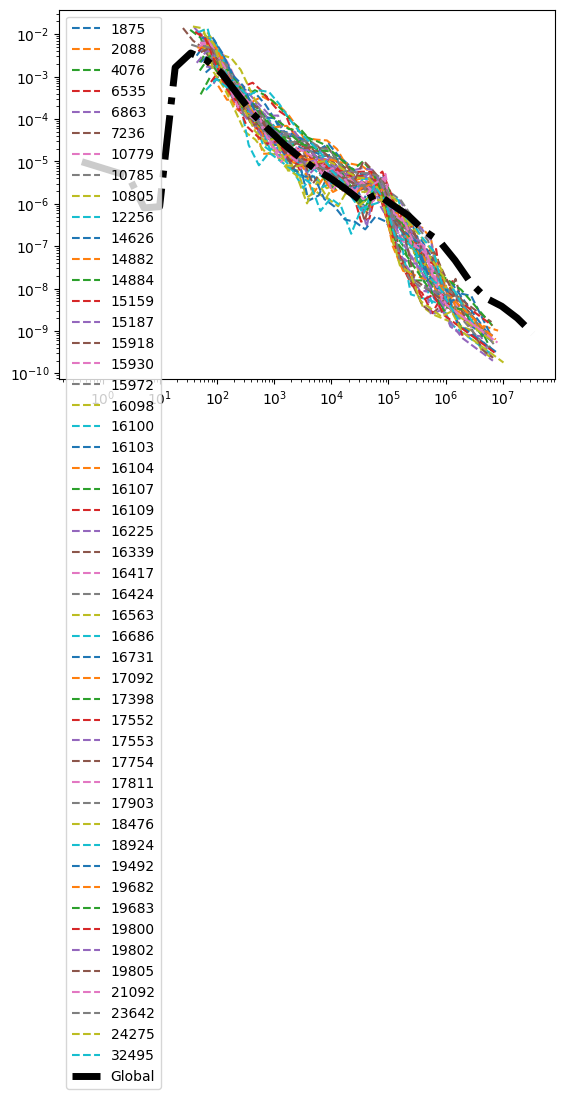

In [57]:
logx = 1
logy = 1
for user in iets:
    h = histogram(iets[user])
    plt.plot(h[0],h[1],ls='--',label=user)

h = histogram(sarafu['iet'])
plt.plot(h[0],h[1],label='Global', ls='-.', color='k', lw=5)
if logx:
    plt.xscale('log')
if logy:
    plt.yscale('log')

plt.legend()
